# Query method coverage comparison

Reads every `*.tsv` result file in this directory and computes coverage (recall) — the % of catalog resources with ≥ 1 result — per query method, against the full `tables/resources-inventory-Jun_8_2026.tab` inventory.

Uses `Resource Name` as the join key, not `Abbreviation` — 38/239 resources have a blank Abbreviation and 14 non-blank Abbreviations are duplicated across distinct resources, so it isn't a reliable unique key here. `Resource Name` has 0 blanks and only 2 duplicates.

This covers recall/coverage only. Precision (via paperclip claim-verification as a relevance oracle over every method's results) is a follow-up, not in this notebook yet.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")

EXPERIMENTS_DIR = Path(".")
INVENTORY_PATH = "../../../../tables/resources-inventory-Jun_8_2026.tab"

In [2]:
inventory_df = pd.read_csv(INVENTORY_PATH, sep="\t", dtype=str)
all_resources = set(inventory_df["Resource Name"].dropna())
print(f"Total resources in catalog: {len(all_resources)}")

Total resources in catalog: 237


In [3]:
tsv_files = sorted(EXPERIMENTS_DIR.glob("*.tsv"))
print(f"Found {len(tsv_files)} result file(s):")
for f in tsv_files:
    print(" -", f.name)

datasets = {}
for f in tsv_files:
    label = f.stem  # e.g. "q1_pmc_full"
    df = pd.read_csv(f, sep="\t", dtype=str)
    datasets[label] = df

Found 10 result file(s):
 - paperclip_full.tsv
 - q1_pmc_full.tsv
 - q1_pubmed_full.tsv
 - q2_pmc_full.tsv
 - q2_pubmed_full.tsv
 - q3_pmc_full.tsv
 - q3_pubmed_full.tsv
 - q4_pmc_full.tsv
 - q4_pubmed_full.tsv
 - v5_pmc_full.tsv


In [4]:
rows = []
covered_by = {}
for label, df in datasets.items():
    present = set(df["Resource Name"].dropna()) if "Resource Name" in df.columns else set()
    covered = present & all_resources
    unmatched = present - all_resources
    covered_by[label] = covered
    rows.append({
        "Method": label,
        "Total rows": len(df),
        "Resources covered": len(covered),
        "Coverage %": round(len(covered) / len(all_resources) * 100, 1),
        "Unrecognized resource names": len(unmatched),
    })

coverage_df = pd.DataFrame(rows).sort_values("Coverage %", ascending=False).reset_index(drop=True)
coverage_df

,Method,Total rows,Resources covered,Coverage %,Unrecognized resource names
0,paperclip_full,1155,235,99.2,0
1,v5_pmc_full,21322,233,98.3,0
2,q1_pmc_full,6400,132,55.7,0
3,q2_pmc_full,3640,115,48.5,0
4,q4_pmc_full,3099,115,48.5,0
5,q2_pubmed_full,3206,99,41.8,0
6,q4_pubmed_full,2438,99,41.8,0
7,q1_pubmed_full,2840,95,40.1,0
8,q3_pmc_full,1574,76,32.1,0
9,q3_pubmed_full,1474,73,30.8,0


In [5]:
out_csv = EXPERIMENTS_DIR / "coverage_summary.csv"
coverage_df.to_csv(out_csv, index=False)
print(f"Saved \u2192 {out_csv}")

Saved → coverage_summary.csv


Saved → coverage_comparison.png


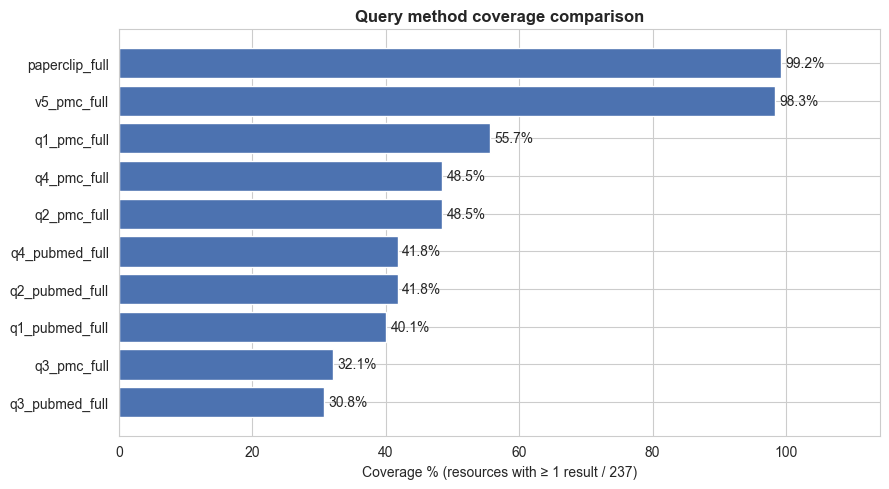

In [6]:
order = coverage_df.sort_values("Coverage %")
fig, ax = plt.subplots(figsize=(9, max(3, 0.5 * len(order))))
bars = ax.barh(order["Method"], order["Coverage %"], color="#4C72B0")
ax.set_xlabel(f"Coverage % (resources with \u2265 1 result / {len(all_resources)})")
ax.set_title("Query method coverage comparison", fontweight="bold")
ax.bar_label(bars, fmt="%.1f%%", padding=3)
ax.set_xlim(0, max(order["Coverage %"].max() * 1.15, 10))
plt.tight_layout()

out_png = EXPERIMENTS_DIR / "coverage_comparison.png"
fig.savefig(out_png, dpi=180, bbox_inches="tight")
print(f"Saved \u2192 {out_png}")
plt.show()

## Union / intersection across methods

How much does combining methods actually buy you, and which resources still have zero coverage from anything tried so far?

In [ ]:
union_covered = set().union(*covered_by.values()) if covered_by else set()
intersection_covered = set.intersection(*covered_by.values()) if covered_by else set()
never_covered = all_resources - union_covered

print(f"Covered by ANY method:  {len(union_covered)}/{len(all_resources)} ({len(union_covered) / len(all_resources) * 100:.1f}%)")
print(f"Covered by ALL methods: {len(intersection_covered)}/{len(all_resources)} ({len(intersection_covered) / len(all_resources) * 100:.1f}%)")
print(f"Never covered by anything tried so far: {len(never_covered)}")

In [ ]:
sorted(never_covered)